In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pandaprosumer.run_time_series import run_timeseries
from pandaprosumer.mapping import GenericMapping, FluidMixMapping

from pandaprosumer import create_period, DFData, create_empty_prosumer_container, \
    create_controlled_const_profile, create_controlled_gas_boiler, create_controlled_heat_demand

In [2]:
# Parameters for demand profile illustration
max_power_kw = 100
min_power_kw = 10

# Create a realistic demand profile over 48 hours with hourly resolution
# This profile illustrates: low demand periods, ramp up/down constraints, and min power threshold
hours = 48
demand_profile = [
    # Night period (low demand)
    0, 0, 0, 3, 5, 8,  # 0-5h: very low/off
    # Morning ramp up
    15, 30, 50, 70, 85, 90,  # 6-11h: gradual increase (ramp up ~15 kW/h)
    # Daytime peak
    95, 98, 100, 100, 98, 95,  # 12-17h: peak operation
    # Afternoon decline
    80, 60, 45, 30, 20, 15,  # 18-23h: gradual decrease (ramp down ~15 kW/h)
    # Evening low
    10, 5, 3, 0, 0, 0,  # 24-29h: low operation
    # Night to morning
    8, 20, 40, 65, 85, 98,  # 30-35h: another ramp up
    # High demand
    103, 108, 105, 90, 75, 60,  # 36-41h: sustained operation
    # Final ramp down
    40, 25, 25, 0, 0, 0,  # 42-47h: ramp down to off
]

prosumer = create_empty_prosumer_container()
data = pd.DataFrame({"demand_1": demand_profile})

start = '2020-01-01 00:00:00'
resol = 3600  # 1 hour resolution in seconds
end = pd.Timestamp(start) + len(data["demand_1"]) * pd.Timedelta(f"00:00:{resol}") - pd.Timedelta("00:00:01")
dur = pd.date_range(start, end, freq='%dS' % resol, tz='utc')
data.index = dur
data_source = DFData(data)

period = create_period(prosumer,
                        resol,
                        start,
                        end,
                        'utc',
                        'default')

cp_input_columns = ["demand_1"]
cp_result_columns = ["qdemand_kw"]

max_ramp_up_kw_per_s = 15/3600 # 0.004
max_ramp_down_kw_per_s = 15/3600
lhv = 20e3
gb_params = {
        'max_q_kw': max_power_kw,
        'min_q_kw': min_power_kw,
        'max_ramp_up_kw_per_s': max_ramp_up_kw_per_s,
        'max_ramp_down_kw_per_s': max_ramp_down_kw_per_s,
        'heating_value_kj_per_kg': lhv,
        'name': 'biomass_boiler'
    }

hd_params = {'t_in_set_c': 76.85, 
             't_out_set_c': 30, 
             'name': 'heat_demand'}

cp_controller_index = create_controlled_const_profile(prosumer, cp_input_columns, cp_result_columns,
                                                        data_source, period, 0, 0)

gb_controller_index = create_controlled_gas_boiler(prosumer, period=period, level=1, order=0, **gb_params)

hd_controller_index = create_controlled_heat_demand(prosumer, period=period, level=1, order=1, **hd_params)

GenericMapping(container=prosumer,
                initiator_id=cp_controller_index,
                initiator_column="qdemand_kw",
                responder_id=hd_controller_index,
                responder_column="q_demand_kw",
                order=1)

FluidMixMapping(container=prosumer,
                initiator_id=gb_controller_index,
                responder_id=hd_controller_index,
                order=0)

run_timeseries(prosumer, period, True)

/tmp/ipykernel_103621/2238389666.py:33: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  dur = pd.date_range(start, end, freq='%dS' % resol, tz='utc')
100%|██████████| 48/48 [00:00<00:00, 149.92it/s]


In [3]:
res_df = prosumer.time_series.copy()
res_df.set_index('name', inplace=True)

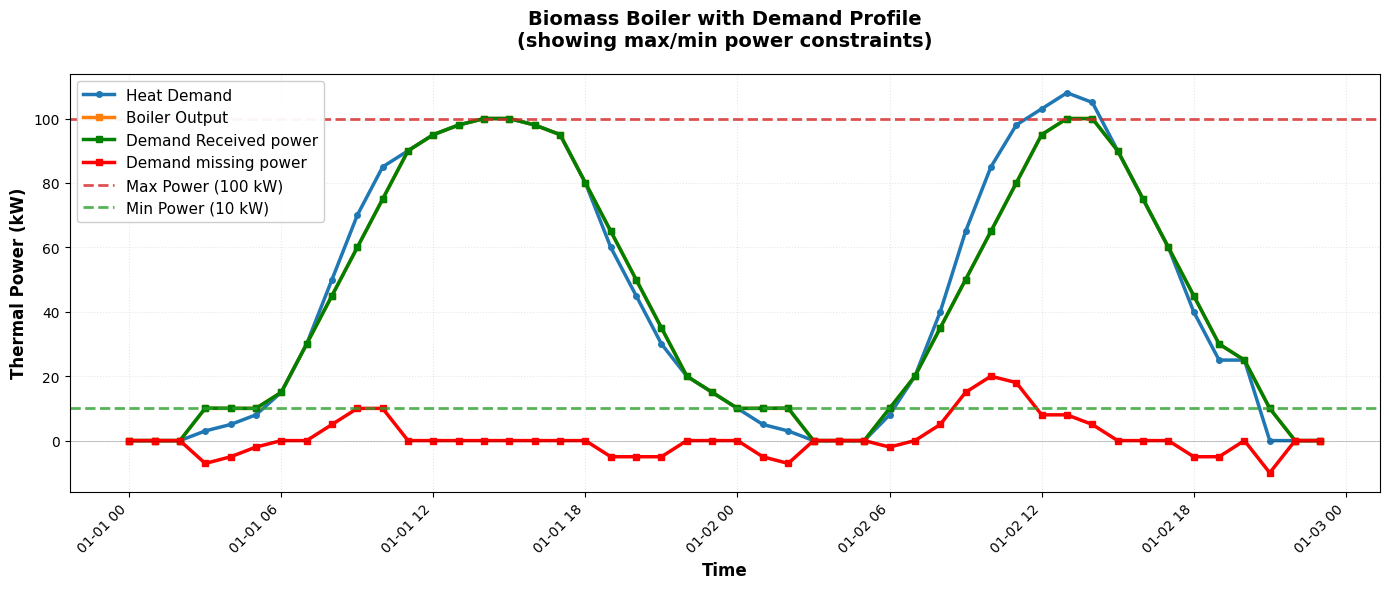

In [4]:
# Extract results
boiler_output = res_df.data_source.loc['biomass_boiler'].df.q_kw
demand_output = res_df.data_source.loc['heat_demand'].df.q_received_kw
demand_missing = res_df.data_source.loc['heat_demand'].df.q_uncovered_kw

# Create a nice plot showing demand, boiler output, and constraints
fig, ax = plt.subplots(figsize=(14, 6))

# Plot input demand
ax.plot(data.index, data['demand_1'], linewidth=2.5, label='Heat Demand', 
        color='#1f77b4', marker='o', markersize=4)

# Plot boiler output
ax.plot(boiler_output.index, boiler_output.values, linewidth=2.5, label='Boiler Output', 
        color='#ff7f0e', marker='s', markersize=4)

# Plot demand output
ax.plot(demand_output.index, demand_output.values, linewidth=2.5, label='Demand Received power', 
        color='green', marker='s', markersize=4)
ax.plot(demand_missing.index, demand_missing.values, linewidth=2.5, label='Demand missing power', 
        color='red', marker='s', markersize=4)

# Add constraint lines
ax.axhline(y=max_power_kw, color='#d62728', linestyle='--', linewidth=2, 
           label=f'Max Power ({max_power_kw} kW)', alpha=0.8)
ax.axhline(y=min_power_kw, color='#2ca02c', linestyle='--', linewidth=2, 
           label=f'Min Power ({min_power_kw} kW)', alpha=0.8)
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5, alpha=0.3)

# Formatting
ax.set_xlabel('Time', fontsize=12, fontweight='bold')
ax.set_ylabel('Thermal Power (kW)', fontsize=12, fontweight='bold')
ax.set_title('Biomass Boiler with Demand Profile\n(showing max/min power constraints)', 
             fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='best', fontsize=11, framealpha=0.95)
ax.grid(True, alpha=0.3, linestyle=':')
fig.autofmt_xdate(rotation=45, ha='right')
plt.tight_layout()
plt.show()


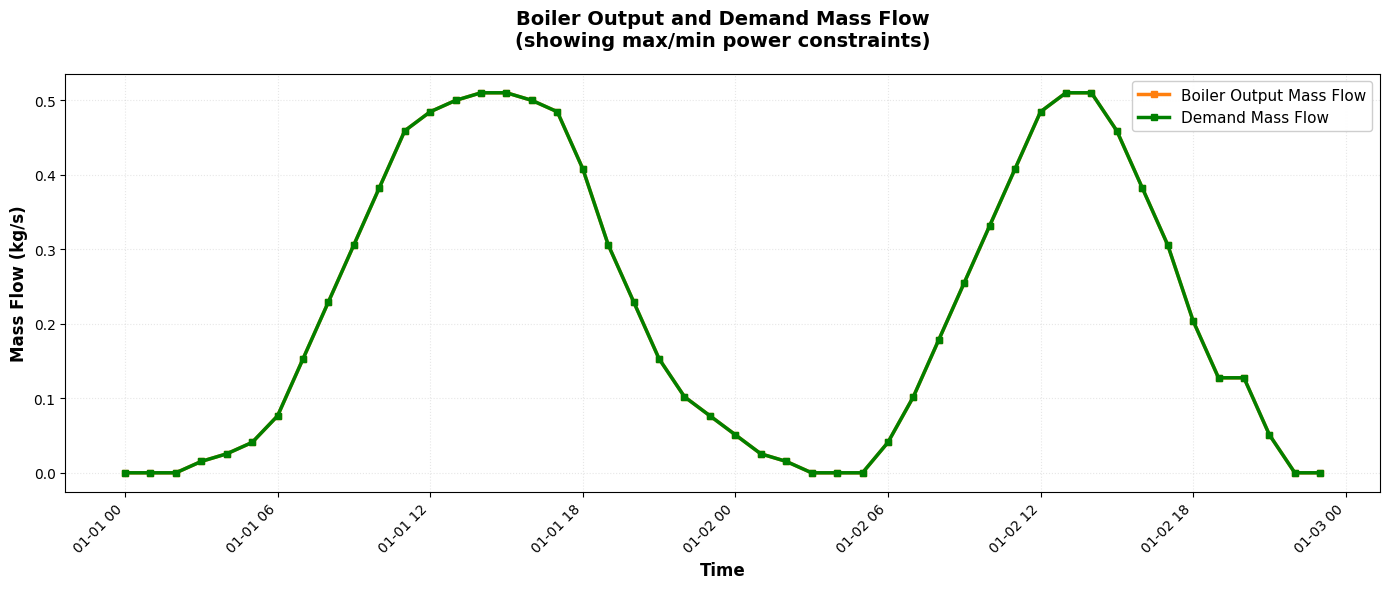

In [5]:
# Create another figure for mass flow
boiler_output_mass = res_df.data_source.loc['biomass_boiler'].df.mdot_kg_per_s
demand_mass = res_df.data_source.loc['heat_demand'].df.mdot_kg_per_s


fig, ax = plt.subplots(figsize=(14, 6))

# Plot boiler output mass flow
ax.plot(boiler_output_mass.index, boiler_output_mass.values, linewidth=2.5, label='Boiler Output Mass Flow', 
        color='#ff7f0e', marker='s', markersize=4)
ax.plot(demand_mass.index, demand_mass.values, linewidth=2.5, label='Demand Mass Flow', 
        color='green', marker='s', markersize=4)

ax.set_xlabel('Time', fontsize=12, fontweight='bold')
ax.set_ylabel('Mass Flow (kg/s)', fontsize=12, fontweight='bold')
ax.set_title('Boiler Output and Demand Mass Flow\n(showing max/min power constraints)', 
             fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='best', fontsize=11, framealpha=0.95)
ax.grid(True, alpha=0.3, linestyle=':')
fig.autofmt_xdate(rotation=45, ha='right')
plt.tight_layout()

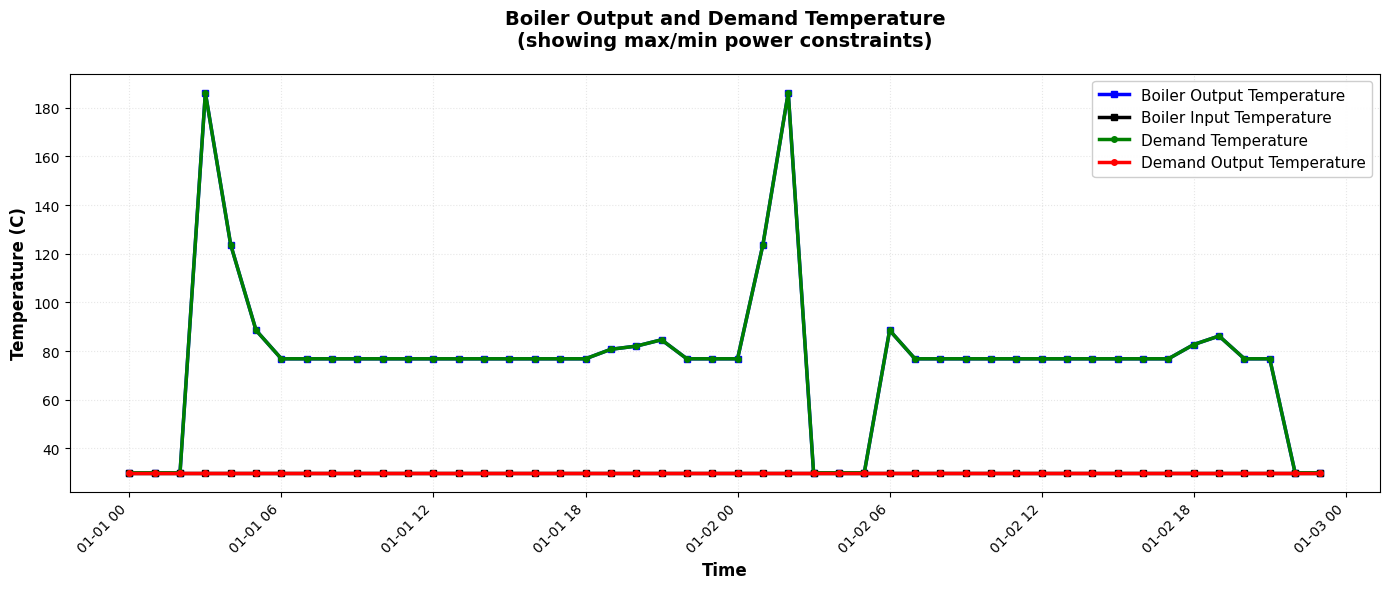

In [6]:
# Graph for temperature
boiler_output_temp = res_df.data_source.loc['biomass_boiler'].df.t_out_c
boiler_input_temp = res_df.data_source.loc['biomass_boiler'].df.t_in_c
demand_temp = res_df.data_source.loc['heat_demand'].df.t_in_c
demand_output_temp = res_df.data_source.loc['heat_demand'].df.t_out_c

fig, ax = plt.subplots(figsize=(14, 6))

# Plot boiler output temperature
ax.plot(boiler_output_temp.index, boiler_output_temp.values, linewidth=2.5, label='Boiler Output Temperature', 
        color='blue', marker='s', markersize=4)
ax.plot(boiler_input_temp.index, boiler_input_temp.values, linewidth=2.5, label='Boiler Input Temperature', 
        color='black', marker='s', markersize=4)

# Plot demand temperature
ax.plot(demand_temp.index, demand_temp.values, linewidth=2.5, label='Demand Temperature', 
        color='green', marker='o', markersize=4)
ax.plot(demand_output_temp.index, demand_output_temp.values, linewidth=2.5, label='Demand Output Temperature', 
        color='red', marker='o', markersize=4)

ax.set_xlabel('Time', fontsize=12, fontweight='bold')
ax.set_ylabel('Temperature (C)', fontsize=12, fontweight='bold')
ax.set_title('Boiler Output and Demand Temperature\n(showing max/min power constraints)', 
             fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='best', fontsize=11, framealpha=0.95)
ax.grid(True, alpha=0.3, linestyle=':')
fig.autofmt_xdate(rotation=45, ha='right')
plt.tight_layout()
plt.show()
